# COVID Data Analysis Exercise

1. Introduction
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Analysis
6. Conclusions

## 1. Introduction

This project analyzes COVID-19 data using Python and pandas.  
The goal is to explore trends, compare countries, and identify key patterns such as growth rates and peak infection periods.

## 2. Data Loading

In [1]:
import pandas as pd
df = pd.read_csv("owid-covid-data.csv")
df.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,51.938343,0.39,NaN


## 3. Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, missing values, and key statistics.

In [2]:
print("Dataframe shape:", df.shape)

Dataframe shape: (570606, 61)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570606 entries, 0 to 570605
Data columns (total 61 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   country                                     570606 non-null  object 
 1   date                                        570606 non-null  object 
 2   total_cases                                 558258 non-null  float64
 3   new_cases                                   554318 non-null  float64
 4   new_cases_smoothed                          553109 non-null  float64
 5   total_cases_per_million                     558258 non-null  float64
 6   new_cases_per_million                       554318 non-null  float64
 7   new_cases_smoothed_per_million              553109 non-null  float64
 8   total_deaths                                558258 non-null  float64
 9   new_deaths                                  555343 non-null  float64
 

In [4]:
df.isna().sum().sort_values(ascending=False)

human_development_index                    570606
weekly_icu_admissions                      559613
weekly_icu_admissions_per_million          559613
excess_mortality_cumulative_per_million    556867
excess_mortality_cumulative_absolute       556833
                                            ...  
total_cases_per_million                     12348
total_deaths                                12348
total_deaths_per_million                    12348
date                                            0
country                                         0
Length: 61, dtype: int64

In [5]:
df["country"].nunique()

262

In [6]:
print("Nulls total_cases: ", df["total_cases"].isna().sum())
print("Nulls new_cases  : ", df["new_cases"].isna().sum())
print("Max total_cases:", df["total_cases"].max())
print("Max new_cases  :", df["new_cases"].max())

Nulls total_cases:  12348
Nulls new_cases  :  16288
Max total_cases: 779056637.0
Max new_cases  : 8401906.0


### Observation:
There are many null values in 'new_cases'.
'total_cases' seems more complete.
There are many columns with null values which we will not use.

In [7]:
print("Memory usage (MB):", df.memory_usage(deep=True).sum() / 1024**2)

Memory usage (MB): 369.86005783081055


In [8]:
print("Memory usage country    : ", df["country"].memory_usage(deep=True))
print("Memory usage date       : ", df["date"].memory_usage(deep=True))
print("Memory usage total_cases: ", df["total_cases"].memory_usage(deep=True))
print("Memory usage new_cases  : ", df["new_cases"].memory_usage(deep=True))

Memory usage country    :  33564433
Memory usage date       :  33665886
Memory usage total_cases:  4564980
Memory usage new_cases  :  4564980


## 4. Data Cleansing

In this section, we rename columns and select the columns we will be working with.

In [9]:
df = df.rename(columns={"country": "location"})

df["date"] = pd.to_datetime(df["date"])
df["location"] = df["location"].astype("category")

df = df[["location", "date", "total_cases", "new_cases"]]

In [10]:
assert not df.empty, "Dataframe is empty"
assert "location" in df.columns, "Missing column: location"
assert "date" in df.columns, "Missing column: date"

In [11]:
print("Memory usage location: ", df["location"].memory_usage(deep=True))
print("Memory usage date    : ", df["date"].memory_usage(deep=True))

Memory usage location:  1165077
Memory usage date    :  4564980


## 5. Analysis

In this section, we compare COVID-19 trends across selected countries and identify key patterns such as growth dynamics and peak infection periods.

In [12]:
def get_country_data(df, country):
    assert "location" in df.columns, "Falta columna location"
    
    country_df = df[df["location"] == country].copy()
    country_df = country_df.sort_values("date")
    country_df = country_df.dropna(subset=["total_cases"])
    country_df = country_df[country_df["total_cases"] > 0]
    
    assert not country_df.empty, f"No hay datos para {country}"
    
    return country_df

In [13]:
peru = get_country_data(df, "Peru")
peru.head()

,location,date,total_cases,new_cases
395295,Peru,2020-03-07,9.0,9.0
395296,Peru,2020-03-08,9.0,0.0
395297,Peru,2020-03-09,11.0,2.0
395298,Peru,2020-03-10,13.0,2.0
395299,Peru,2020-03-11,15.0,2.0


In [14]:
import matplotlib.pyplot as plt

def compare_countries(df, countries):
    plt.figure(figsize=(10,6))
    
    for country in countries:
        country_df = get_country_data(df, country)
        plt.plot(
            country_df["date"],
            country_df["total_cases"] / 1_000_000,
            label=country,
            linewidth=2
        )
    
    plt.title("COVID Total Cases Comparison", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Total Cases (millions)")
    
    plt.legend()
    plt.grid(True)
    plt.show()

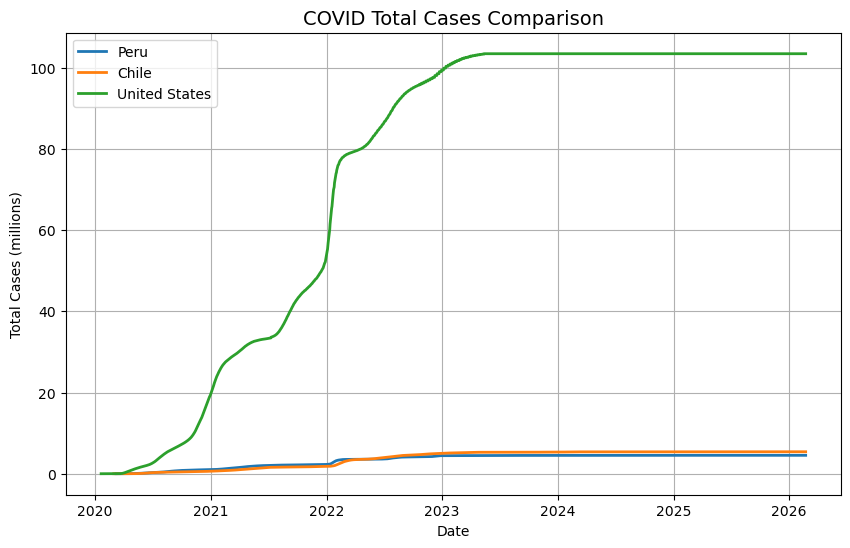

In [15]:
compare_countries(df, ["Peru", "Chile", "United States"])

In [16]:
def compare_growth(df, countries):
    plt.figure(figsize=(10,6))
    
    for country in countries:
        country_df = get_country_data(df, country)
        plt.plot(
            country_df["date"],
            country_df["new_cases"],
            label=country
        )
    
    plt.title("COVID Daily New Cases")
    plt.xlabel("Date")
    plt.ylabel("New Cases")
    
    plt.legend()
    plt.grid(True)
    plt.show()

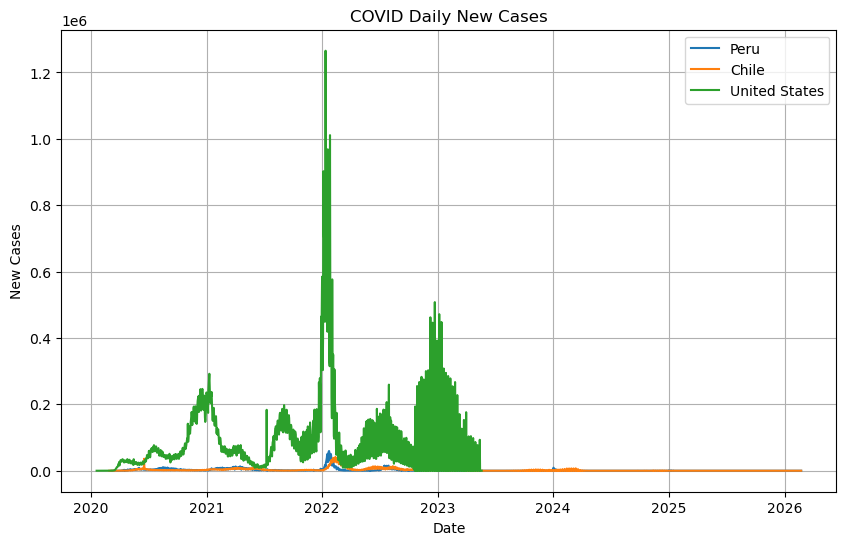

In [17]:
compare_growth(df, ["Peru", "Chile", "United States"])

In [18]:
def get_peak_day(df, country):
    country_df = get_country_data(df, country)
    
    peak = country_df.loc[country_df["new_cases"].idxmax()]
    
    return {
        "date": peak["date"],
        "new_cases": peak["new_cases"]
    }

In [19]:
for country in ["Peru", "Chile", "United States"]:
    peak = get_peak_day(df, country)
    print(f"{country} peak:")
    print(f"Date: {peak['date']}, Cases: {int(peak['new_cases'])}")

Peru peak:
Date: 2022-01-23 00:00:00, Cases: 59470
Chile peak:
Date: 2022-02-12 00:00:00, Cases: 41651
United States peak:
Date: 2022-01-12 00:00:00, Cases: 1265520


## 6. Conclusions

This analysis explored COVID-19 trends across Peru, Chile, and the United States by examining both cumulative cases and daily new infections.

The comparison reveals significant differences in scale as well as clear temporal patterns in the evolution of the pandemic.

- The United States experienced a much larger outbreak in absolute terms, with cumulative cases far exceeding those of Peru and Chile.
- Peru and Chile show broadly similar cumulative growth patterns, although their daily infection peaks differ in magnitude.
- The daily new cases visualization reveals multiple waves of infection in all three countries, indicating that the pandemic progressed through several distinct phases rather than a single continuous surge.

### Insights

Using the peak-day analysis based on daily new cases, we can identify when each country experienced its highest infection surge:

- **Peru:** Peak daily cases occurred on **January 2022** with **~59,000** new cases.
- **Chile:** Peak daily cases occurred on **February 2022** with **~41,000** new cases.
- **United States:** Peak daily cases occurred on **January 2022** with **~1,265,000** new cases.

These peaks illustrate that the most intense infection waves occurred at slightly different times across countries, although they were concentrated within the same general period (January–February 2022).

Overall, combining cumulative trends with daily case dynamics provides a clearer picture of how the pandemic evolved across different regions.